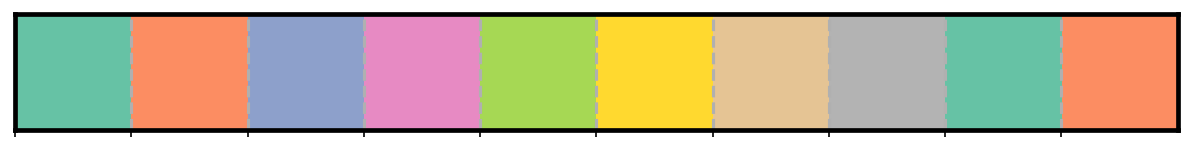

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate
import scipy
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=18, fontsize=30, figsize=(16, 9), dpi=150)

In [2]:
df = pd.read_csv("cpd-crash-incidents.csv", delimiter=";")

In [3]:
df['crash_date']

0        2016-01-01T18:20:09+00:00
1        2016-01-02T15:38:00+00:00
2        2016-01-02T19:21:32+00:00
3        2016-01-02T21:43:21+00:00
4        2016-01-04T14:00:20+00:00
                   ...            
23453    2021-03-12T02:00:45+00:00
23454    2021-03-12T01:18:09+00:00
23455    2021-03-11T22:59:04+00:00
23456    2021-03-12T22:53:57+00:00
23457    2021-03-13T01:45:09+00:00
Name: crash_date, Length: 23458, dtype: str

In [4]:

df['crash_date'] = pd.to_datetime(df['crash_date'])
df['crash_date'] = df['crash_date'].dt.tz_convert('America/Chicago')


df['year'] = df['crash_date'].dt.year
df['month'] = df['crash_date'].dt.month
df['day'] = df['crash_date'].dt.day
df['hour'] = df['crash_date'].dt.hour
df['minute'] = df['crash_date'].dt.minute
df['second'] = df['crash_date'].dt.second
df['date_only'] = df['crash_date'].dt.date
df['time_only'] = df['crash_date'].dt.time
print(df[['crash_date', 'year', 'month', 'day', 'hour']].head())



                 crash_date  year  month  day  hour
0 2016-01-01 12:20:09-06:00  2016      1    1    12
1 2016-01-02 09:38:00-06:00  2016      1    2     9
2 2016-01-02 13:21:32-06:00  2016      1    2    13
3 2016-01-02 15:43:21-06:00  2016      1    2    15
4 2016-01-04 08:00:20-06:00  2016      1    4     8


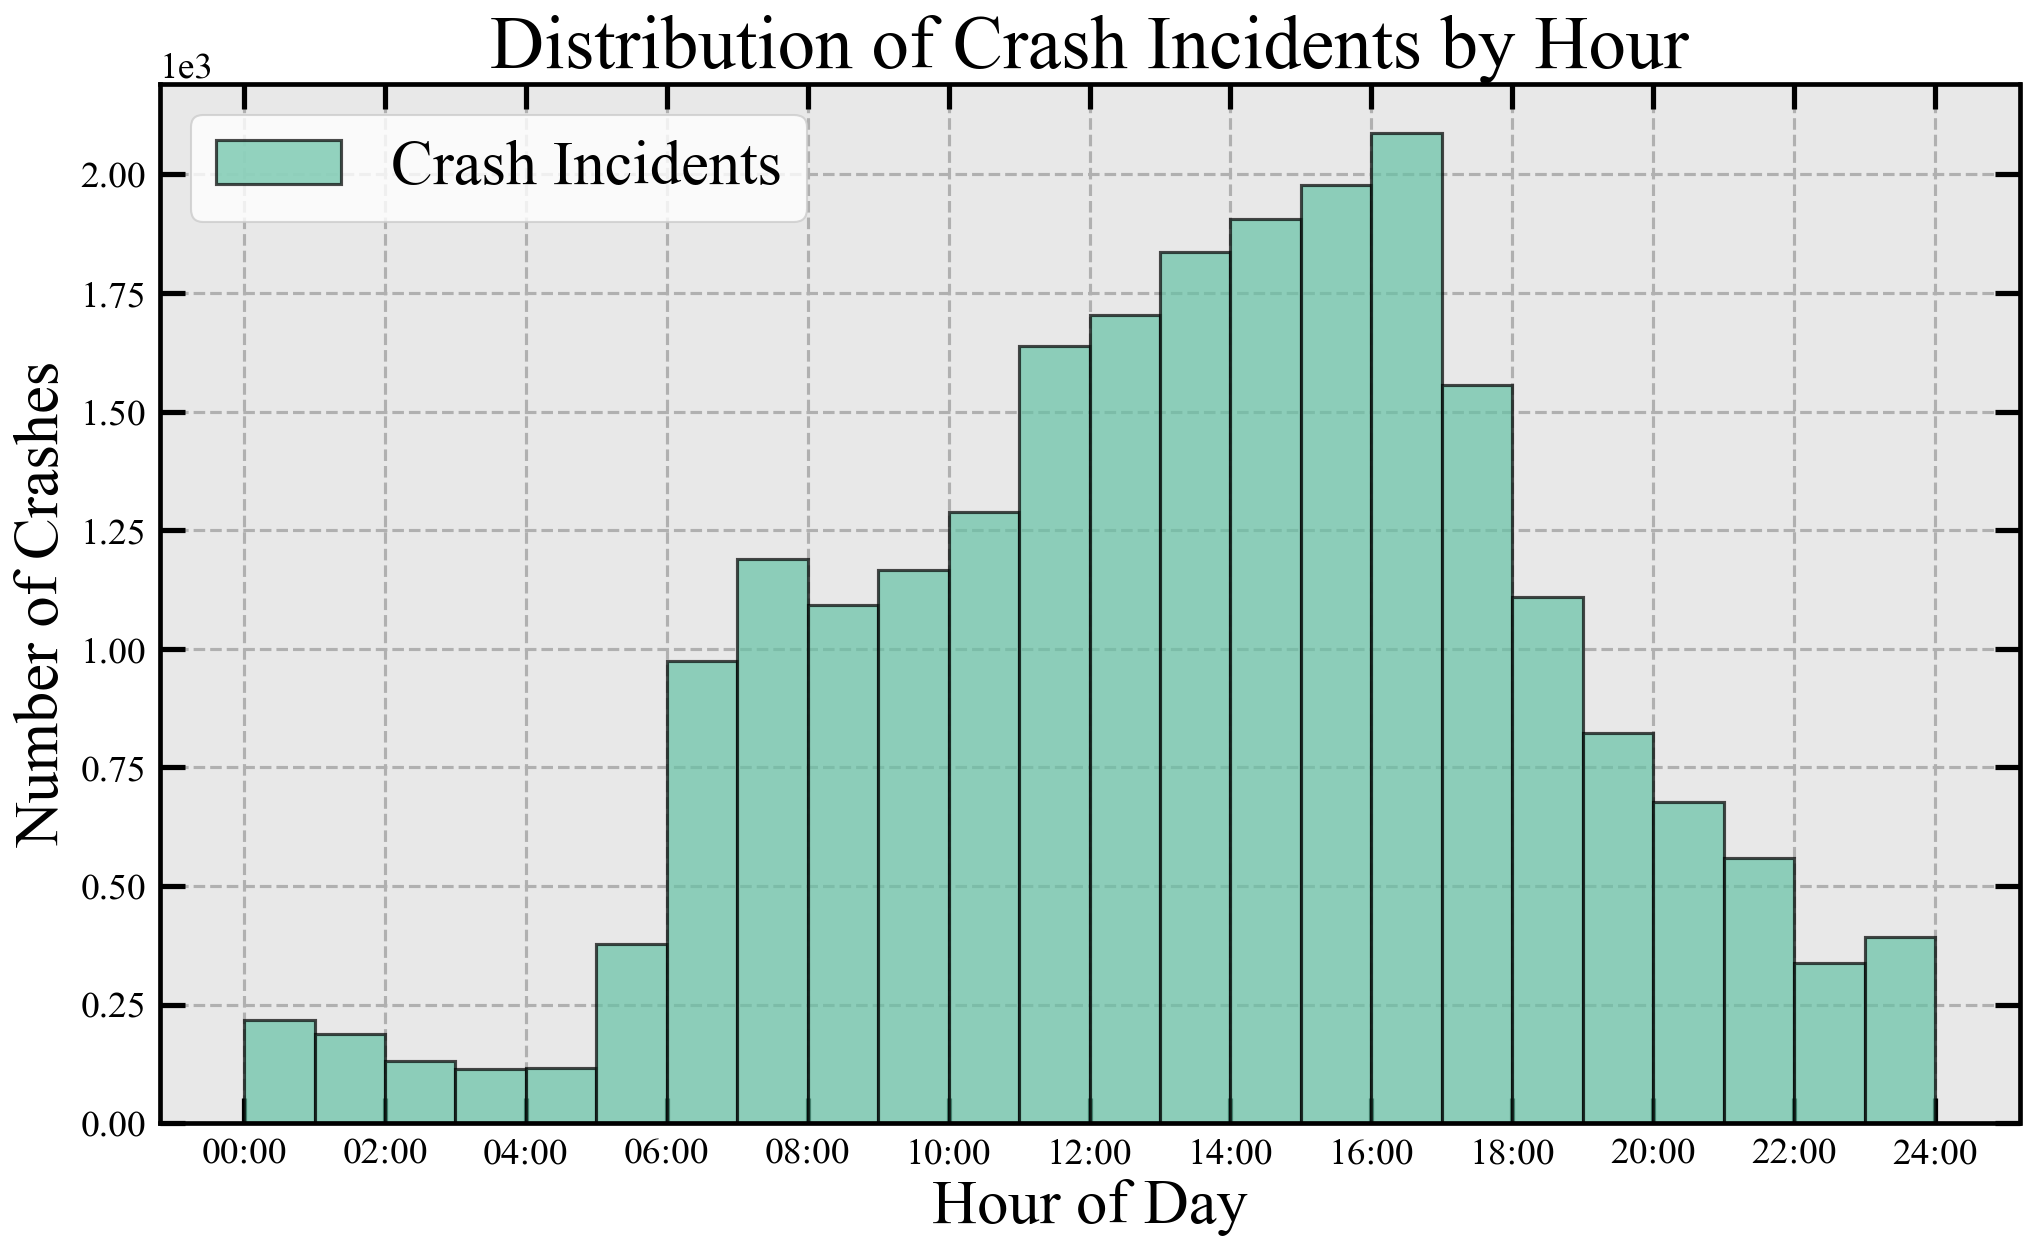

In [5]:
Nbins = 24
x_range = (0.0, 24.0)
counts, edges = np.histogram(df['hour'], bins=Nbins, range=x_range)
bin_centers = (edges[:-1] + edges[1:]) / 2
fig, ax =plt.subplots(figsize=(16, 9), dpi=150)
ax.bar(bin_centers, counts, width=edges[1] - edges[0], color=colors[0], edgecolor="black" ,linewidth=1.5, alpha=0.7, label="Crash Incidents")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.title("Distribution of Crash Incidents by Hour")
plt.xticks(range(0, 25, 2))
ax.set_axisbelow(True)
stylize_ticks(fig, ax)
plt.legend()
plt.xticks(range(0, 25, 2), ['00:00', '02:00', '04:00', '06:00', '08:00', '10:00', '12:00', '14:00', '16:00', '18:00', '20:00', '22:00', '24:00'])
plt.show()



NaN values in longitude: 16779
NaN values in latitude: 16779


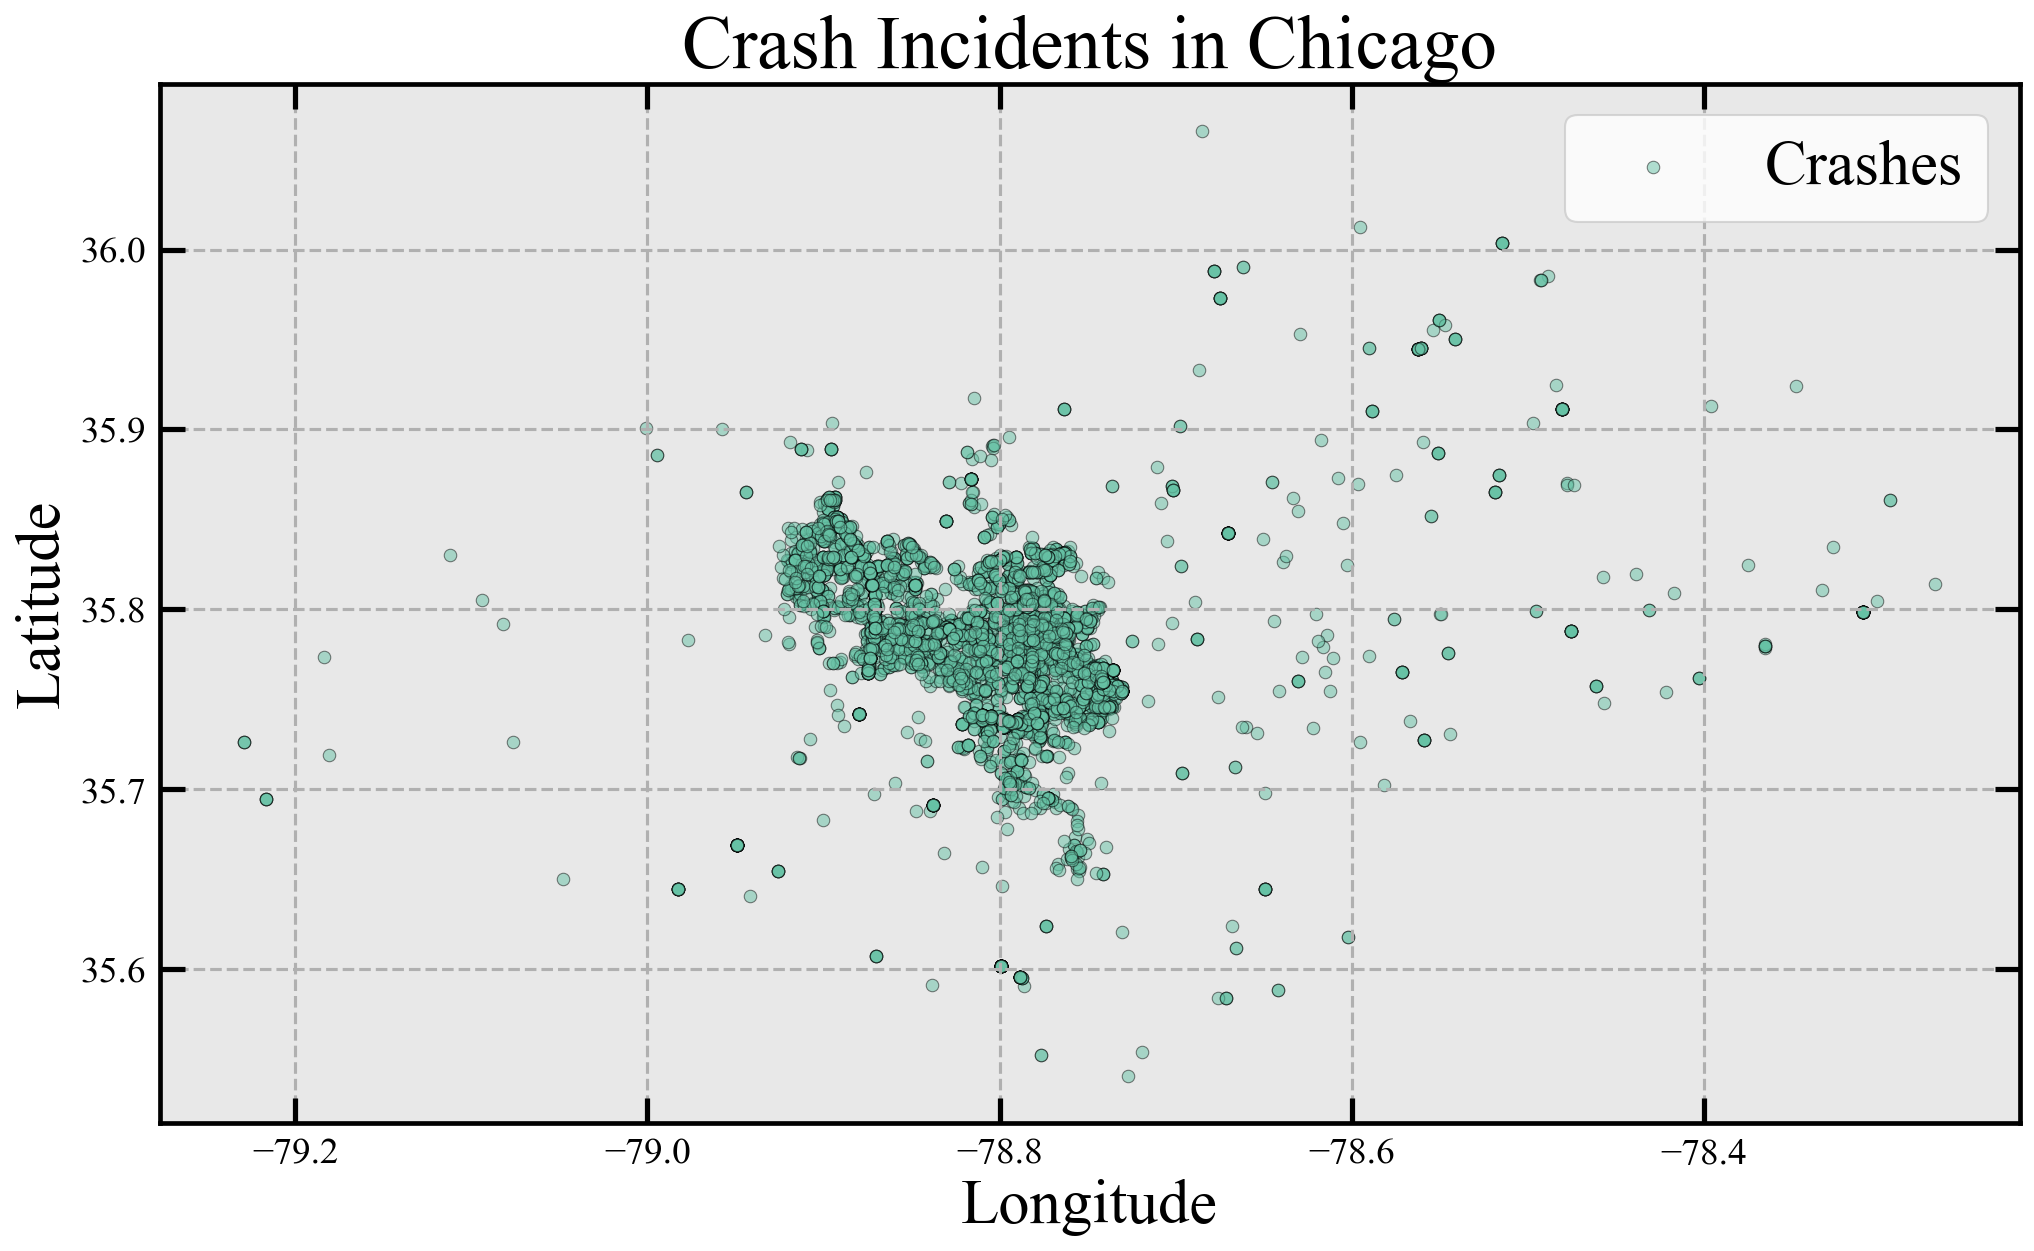

In [6]:
fig, ax = plt.subplots()
longitude = df["lon"]
latitude = df["lat"]
nan_count_lon = longitude.isna().sum()
nan_count_lat = latitude.isna().sum()
print(f"NaN values in longitude: {nan_count_lon}")
print(f"NaN values in latitude: {nan_count_lat}")
ax.scatter(longitude, latitude, alpha=0.5, edgecolors="black", linewidth=0.5, label="Crashes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.title("Crash Incidents in Chicago")
stylize_ticks(fig, ax)
plt.show()

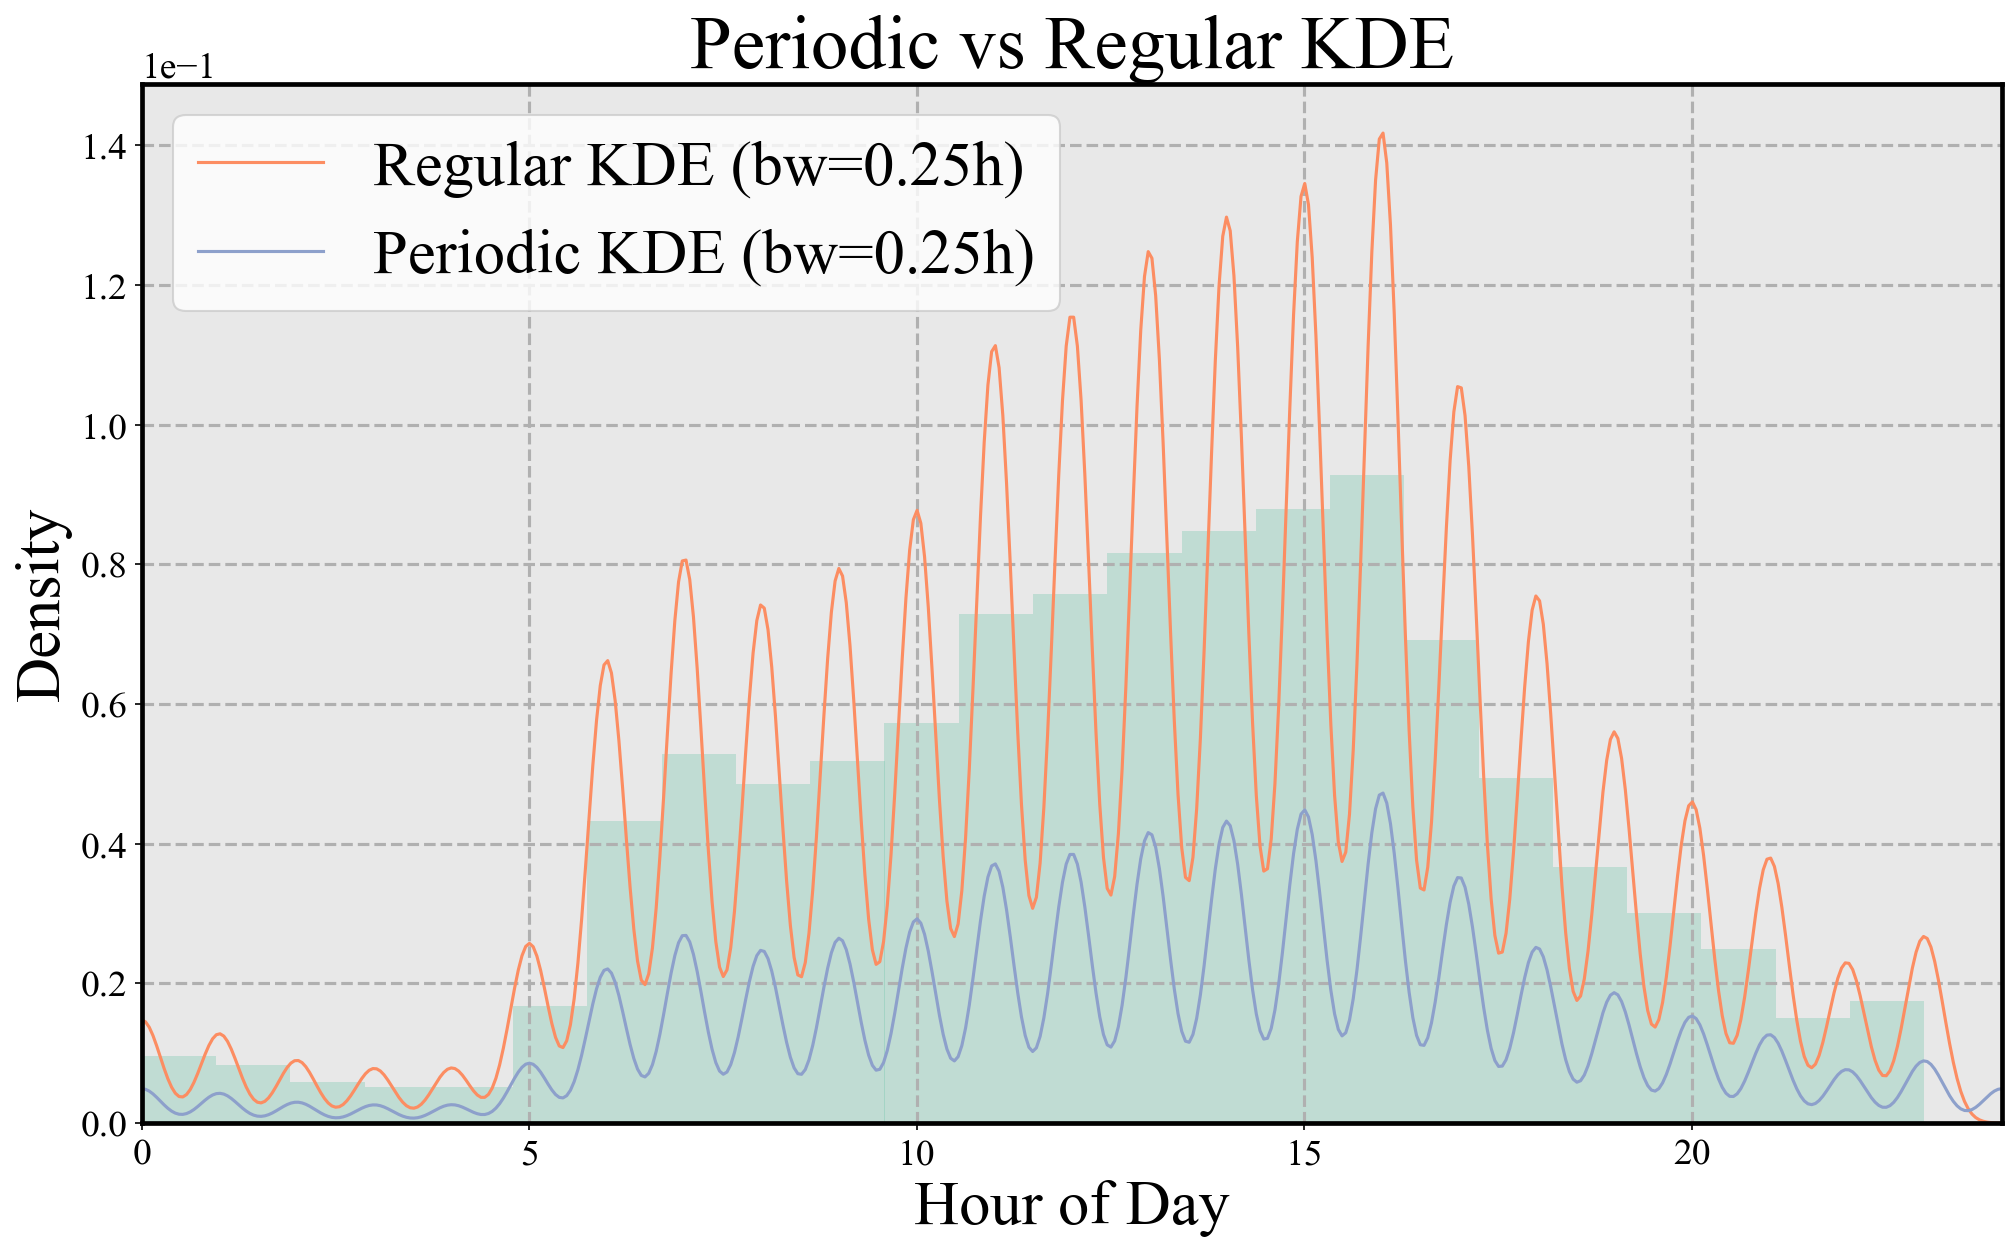

In [7]:



data = df['hour'].to_numpy()
bw = 0.25
factor_regular = bw / np.std(data, ddof=1)
kde_regular = gaussian_kde(data, bw_method=factor_regular)

x = np.linspace(0, 24.0, 500)
density_regular = kde_regular(x)

L = 24.0

data_wrapped = np.concatenate([
    data - L,
    data,
    data + L
])

factor_periodic = bw / np.std(data_wrapped, ddof=1)
kde_periodic = gaussian_kde(data_wrapped, bw_method=factor_periodic)
density_periodic = kde_periodic(x)

plt.figure()
plt.hist(data, bins=24, density=True, alpha=0.3)
plt.plot(x, density_regular, label="Regular KDE (bw=0.25h)")
plt.plot(x, density_periodic, label="Periodic KDE (bw=0.25h)")
plt.xlim(0, 24)
plt.xlabel("Hour of Day")
plt.ylabel("Density")
plt.legend()
plt.title("Periodic vs Regular KDE")
plt.show()


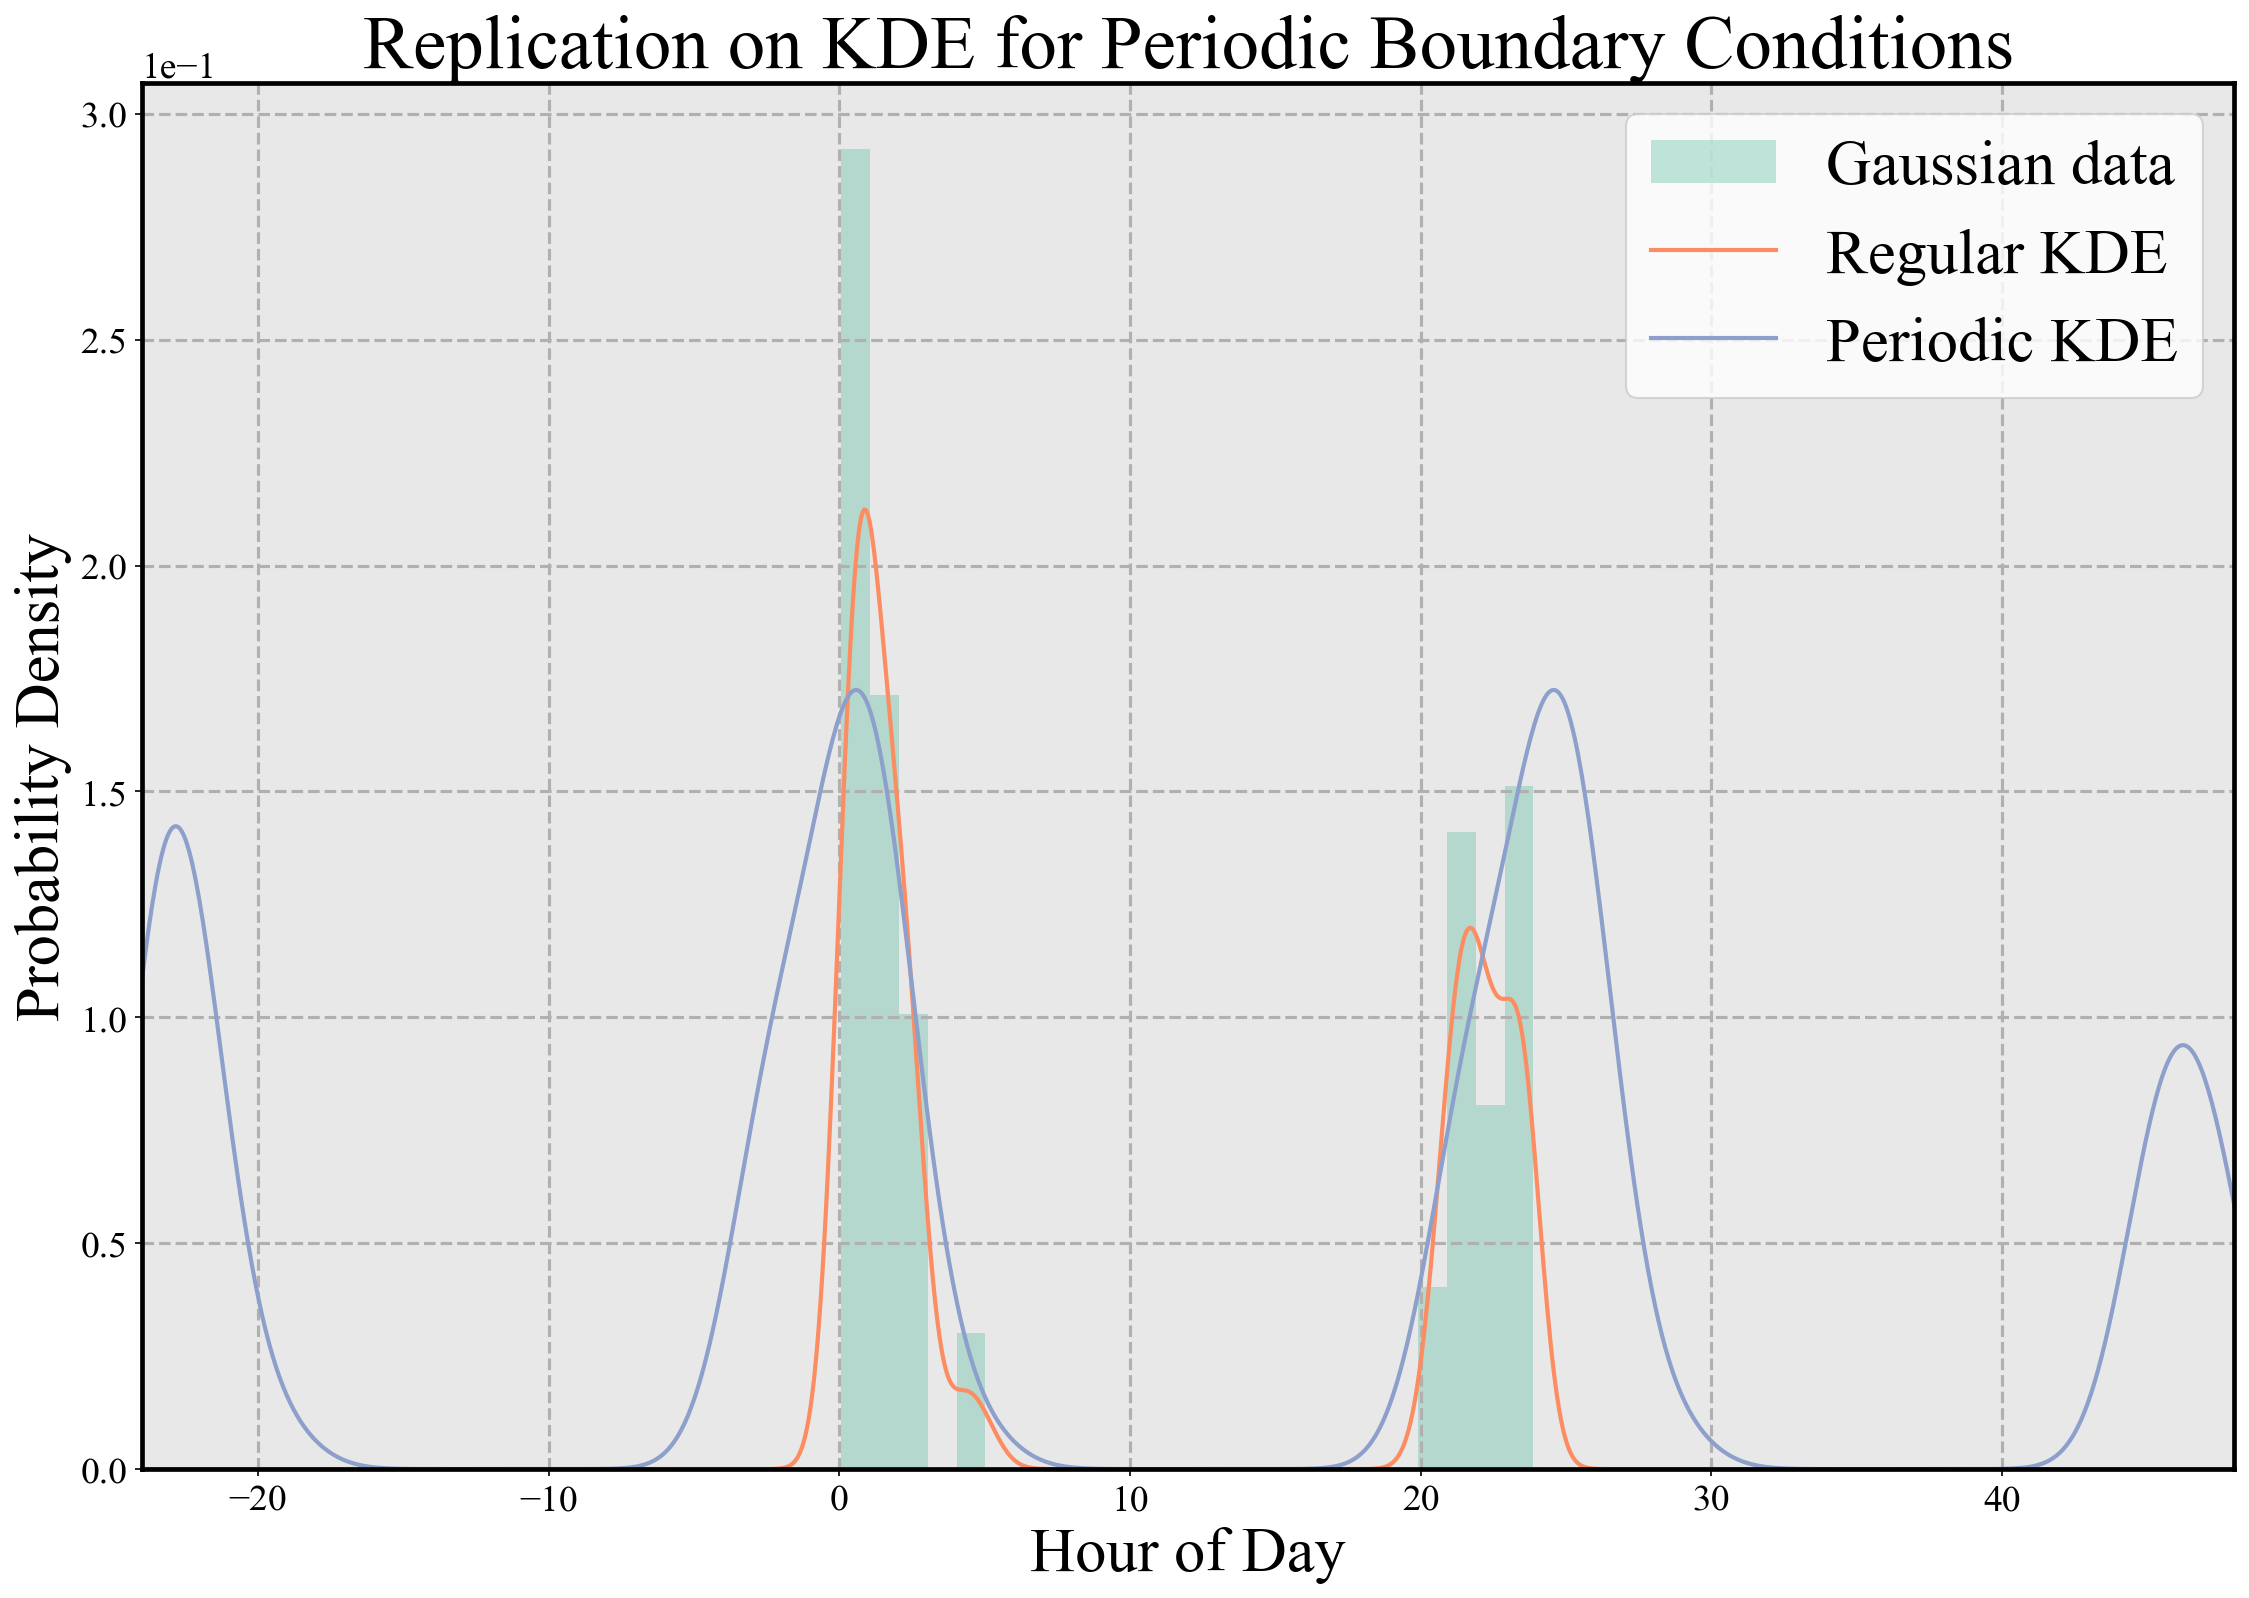

Integral Regular KDE [0,24]: 0.906933
Integral Periodic KDE [0,24]: 1.000000


In [8]:
n = 100
cluster1 = np.random.normal(loc=24.0, scale=2, size=n//2)
cluster2 = np.random.normal(loc=0.0,  scale=2, size=n//2)
data = np.concatenate([cluster1, cluster2]) % 24.0

bw = 0.25
L = 24.0
sigma = np.std(data, ddof=1)
h_scott = sigma * n ** (-1/5)
factor = bw / h_scott
data_wrapped = np.concatenate([data - L, data, data + L])

kde_regular = gaussian_kde(data, bw_method=factor)
kde_periodic = gaussian_kde(data_wrapped, bw_method=factor)

x = np.linspace(-24.0, 48.0, 1200)
density_regular = kde_regular(x)
density_periodic = kde_periodic(x) * 3.0  # normalize copies
fig, ax = plt.subplots(figsize=(18, 12))

ax.hist(data, bins=24, density=True, alpha=0.4, label="Gaussian data")

ax.plot(x, density_regular, label="Regular KDE", linewidth=2)
ax.plot(x, density_periodic, label="Periodic KDE", linewidth=2)

ax.set_xlim(-24, 48)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Probability Density")
ax.set_title("Replication on KDE for Periodic Boundary Conditions")
ax.legend()
plt.show()

x_eval = np.linspace(0.0, 24.0, 2000)
integral_regular = integrate.trapezoid(kde_regular(x_eval), x_eval)
integral_periodic = integrate.trapezoid(kde_periodic(x_eval) * 3.0, x_eval)

print(f"Integral Regular KDE [0,24]: {integral_regular:.6f}")
print(f"Integral Periodic KDE [0,24]: {integral_periodic:.6f}")


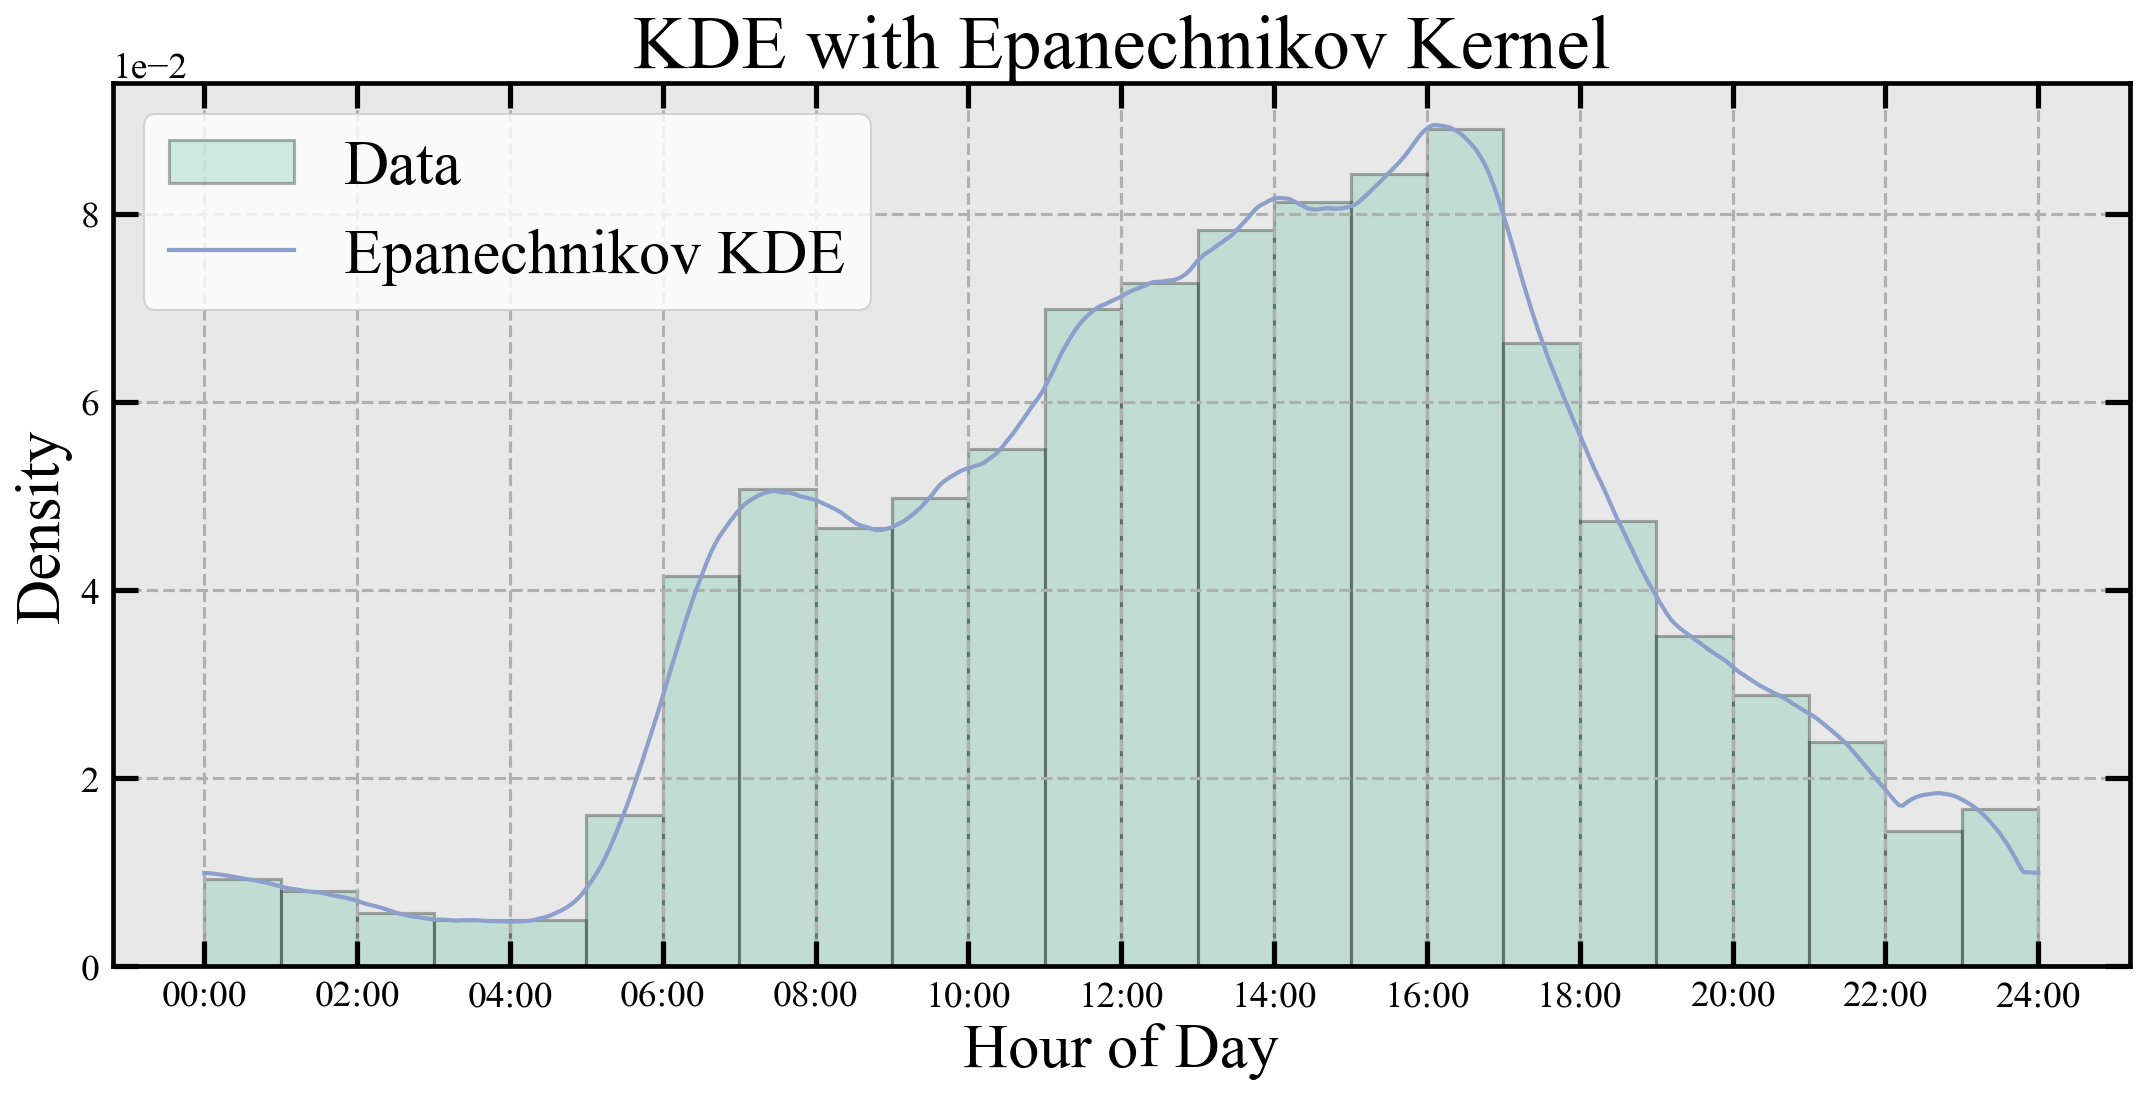

Integral of Epanechnikov KDE (over [0, 24]): 1.000000


In [9]:

data_h = df['hour'].dropna().to_numpy()
data_min = df['minute'].dropna().to_numpy() / 60.0
data_sec = df['second'].dropna().to_numpy() / 3600.0
data = (data_h + data_min + data_sec)

L = 24.0
data_wrapped = np.concatenate([data - L, data, data + L])  # replicate -24, 0, +24
pdf_scale_factor = 3 

data_reshaped = data_wrapped[:, np.newaxis]

bw=0.8
kde = KernelDensity(kernel='epanechnikov', bandwidth=bw)
kde.fit(data_reshaped)
x = np.linspace(0, 24, 500)[:, np.newaxis]
log_density = kde.score_samples(x)
density = np.exp(log_density)*pdf_scale_factor  # convert to actual density

fig, axes = plt.subplots(figsize=(15, 8), dpi=150)

Nbins = 24
x_range = (0.0, 24.0)
axes.hist(data, bins=Nbins, range=x_range, density=True, alpha=0.3, color=colors[0], edgecolor="black", linewidth=1.5, label="Data")
axes.plot(x[:, 0], density, color=colors[2], label="Epanechnikov KDE", linewidth=2)
axes.set_xlabel("Hour of Day")
axes.set_ylabel("Density")
axes.set_title("KDE with Epanechnikov Kernel")
axes.set_xticks(range(0, 25, 2))
axes.set_xticklabels(['00:00', '02:00', '04:00', '06:00', '08:00', '10:00', '12:00', '14:00', '16:00', '18:00', '20:00', '22:00', '24:00'])
axes.legend()
stylize_ticks(fig, axes)

plt.tight_layout()
plt.show()

x_eval = np.linspace(0, 24, 1000)
log_density_epi = kde.score_samples(x_eval[:, np.newaxis])
density_epi = np.exp(log_density_epi)

integral_epi = integrate.trapezoid(density_epi, x_eval)*pdf_scale_factor

print(f"Integral of Epanechnikov KDE (over [0, 24]): {integral_epi:.6f}")


In [10]:
test_hours = np.array([0.3833, 1.8167, 8.2000, 15.9167, 18.0333, 21.2000, 23.7333])
log_dens = kde.score_samples(test_hours[:, np.newaxis])
dens = np.exp(log_dens)*pdf_scale_factor

print("\nEpanechnikov KDE at specific hours (periodic):")
print("Hour | Density")
print("-----|--------")
for h, d in zip(test_hours, dens):
    print(f"{h:4.4f} | {d:7.5f}")


Epanechnikov KDE at specific hours (periodic):
Hour | Density
-----|--------
0.3833 | 0.00949
1.8167 | 0.00732
8.2000 | 0.04880
15.9167 | 0.08842
18.0333 | 0.05587
21.2000 | 0.02569
23.7333 | 0.01097


In [11]:
x_eval = np.linspace(0, 24, 1000)
f_eval = np.exp(kde.score_samples(x_eval[:, np.newaxis]))*pdf_scale_factor
window_width = 2.0  

best_fraction = 0
best_start = None

for start in x_eval:
    end = start + window_width
    
    if end <= 24:
        mask = (x_eval >= start) & (x_eval <= end)
        frac = integrate.trapezoid(f_eval[mask], x_eval[mask])
    else:  
        mask1 = x_eval >= start
        mask2 = x_eval <= (end - 24)
        frac = integrate.trapezoid(f_eval[mask1], x_eval[mask1]) + integrate.trapezoid(f_eval[mask2], x_eval[mask2])
    
    if frac > best_fraction:
        best_fraction = frac
        best_start = start



In [12]:
print(best_fraction)

reduction_percent = best_fraction * 0.10 * 100
best_end = (best_start + window_width) % 24

# Convert decimal hours to hours, minutes, seconds
start_h = int(best_start)
start_m_frac = (best_start - start_h) * 60
start_m = int(start_m_frac)
start_s = int((start_m_frac - start_m) * 60)

end_h = int(best_end)
end_m_frac = (best_end - end_h) * 60
end_m = int(end_m_frac)
end_s = int((end_m_frac - end_m) * 60)

print(f"Best 2-hour window: {start_h:02d}:{start_m:02d}:{start_s:02d}–{end_h:02d}:{end_m:02d}:{end_s:02d}")
print(f"Expected reduction in total daily crashes: {reduction_percent:.2f}%")

0.17101914054981926
Best 2-hour window: 14:58:01–16:58:01
Expected reduction in total daily crashes: 1.71%


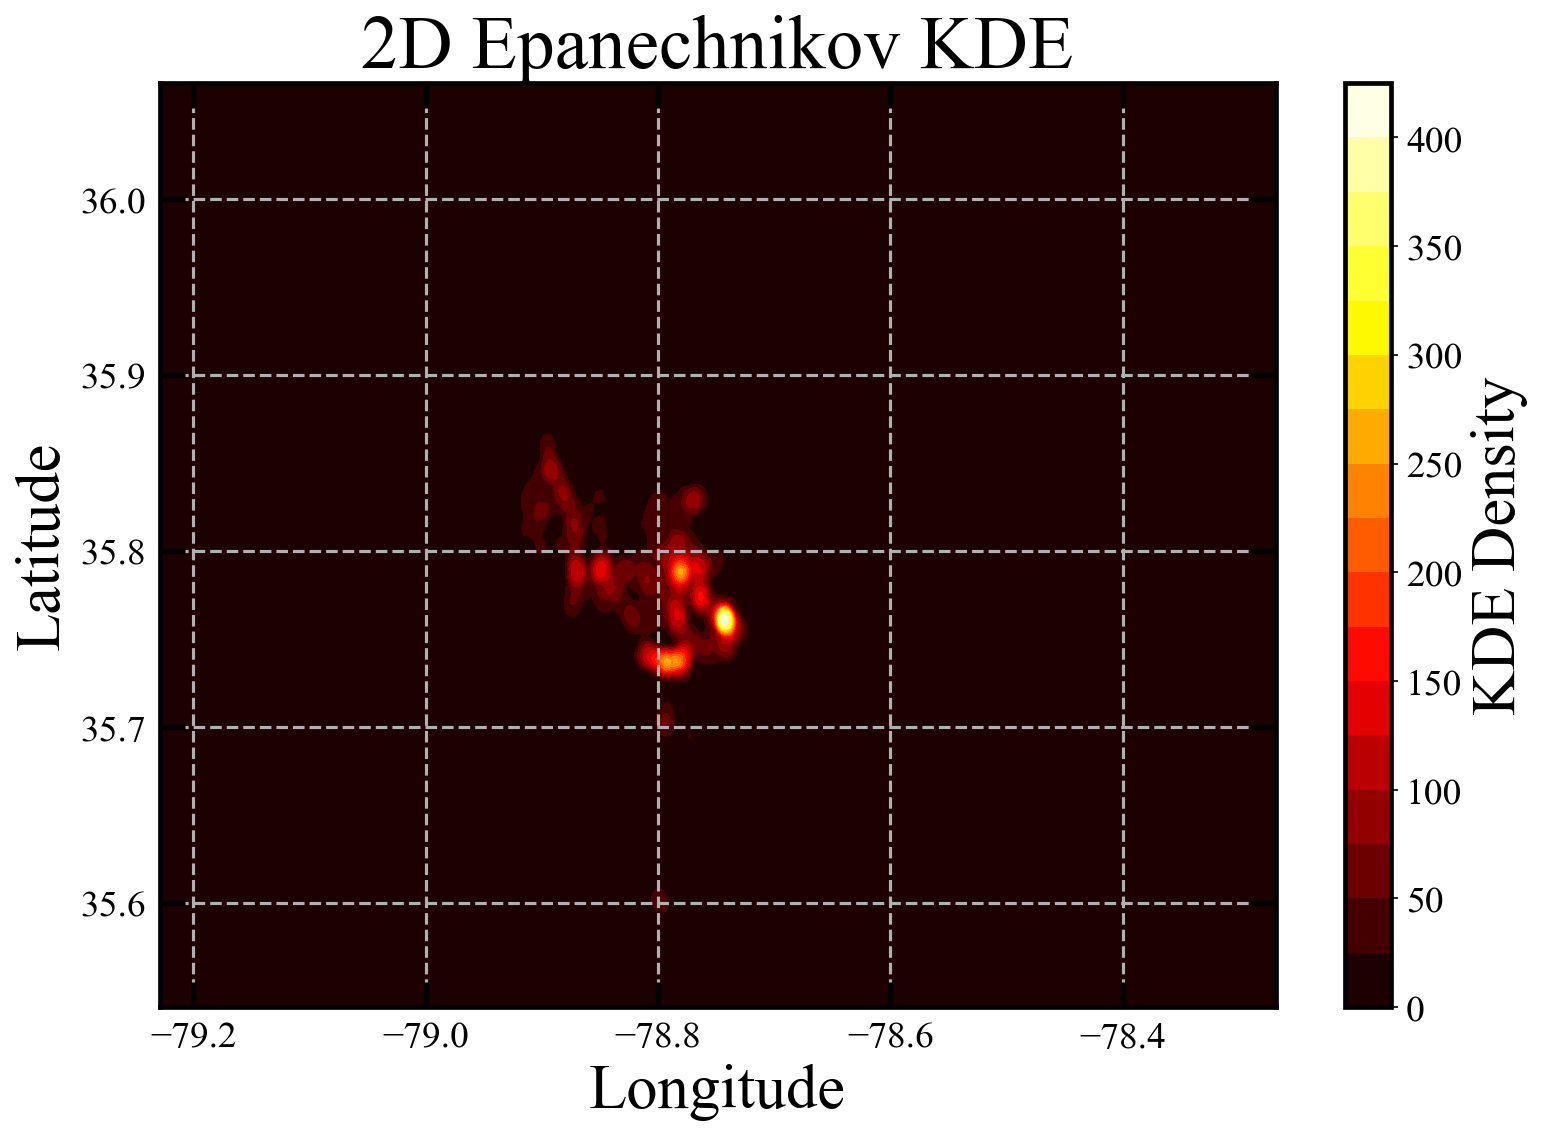

424.66577839964845


In [13]:
longitude = df["lon"].to_numpy()
latitude = df["lat"].to_numpy()


valid = np.isfinite(longitude) & np.isfinite(latitude)
longitude = longitude[valid]
latitude = latitude[valid]

data_2d = np.column_stack([longitude, latitude]) 

bw = 0.01
kde_2d = KernelDensity(kernel='epanechnikov', bandwidth=bw)
kde_2d.fit(data_2d)


lon_axis = np.linspace(longitude.min(), longitude.max(), 500)
lat_axis = np.linspace(latitude.min(), latitude.max(), 500)
LO, LA = np.meshgrid(lon_axis, lat_axis)

grid_points = np.column_stack([LO.ravel(), LA.ravel()])

log_density_2d = kde_2d.score_samples(grid_points)
density_2d = np.exp(log_density_2d).reshape(LO.shape)
fig, ax = plt.subplots(figsize=(12, 8))
contour = ax.contourf(LO, LA, density_2d, levels=20, cmap='hot')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("2D Epanechnikov KDE")
cbar = plt.colorbar(contour, ax=ax, label=f"KDE Density")

stylize_ticks(fig, ax)
plt.show()
print(np.max(density_2d))

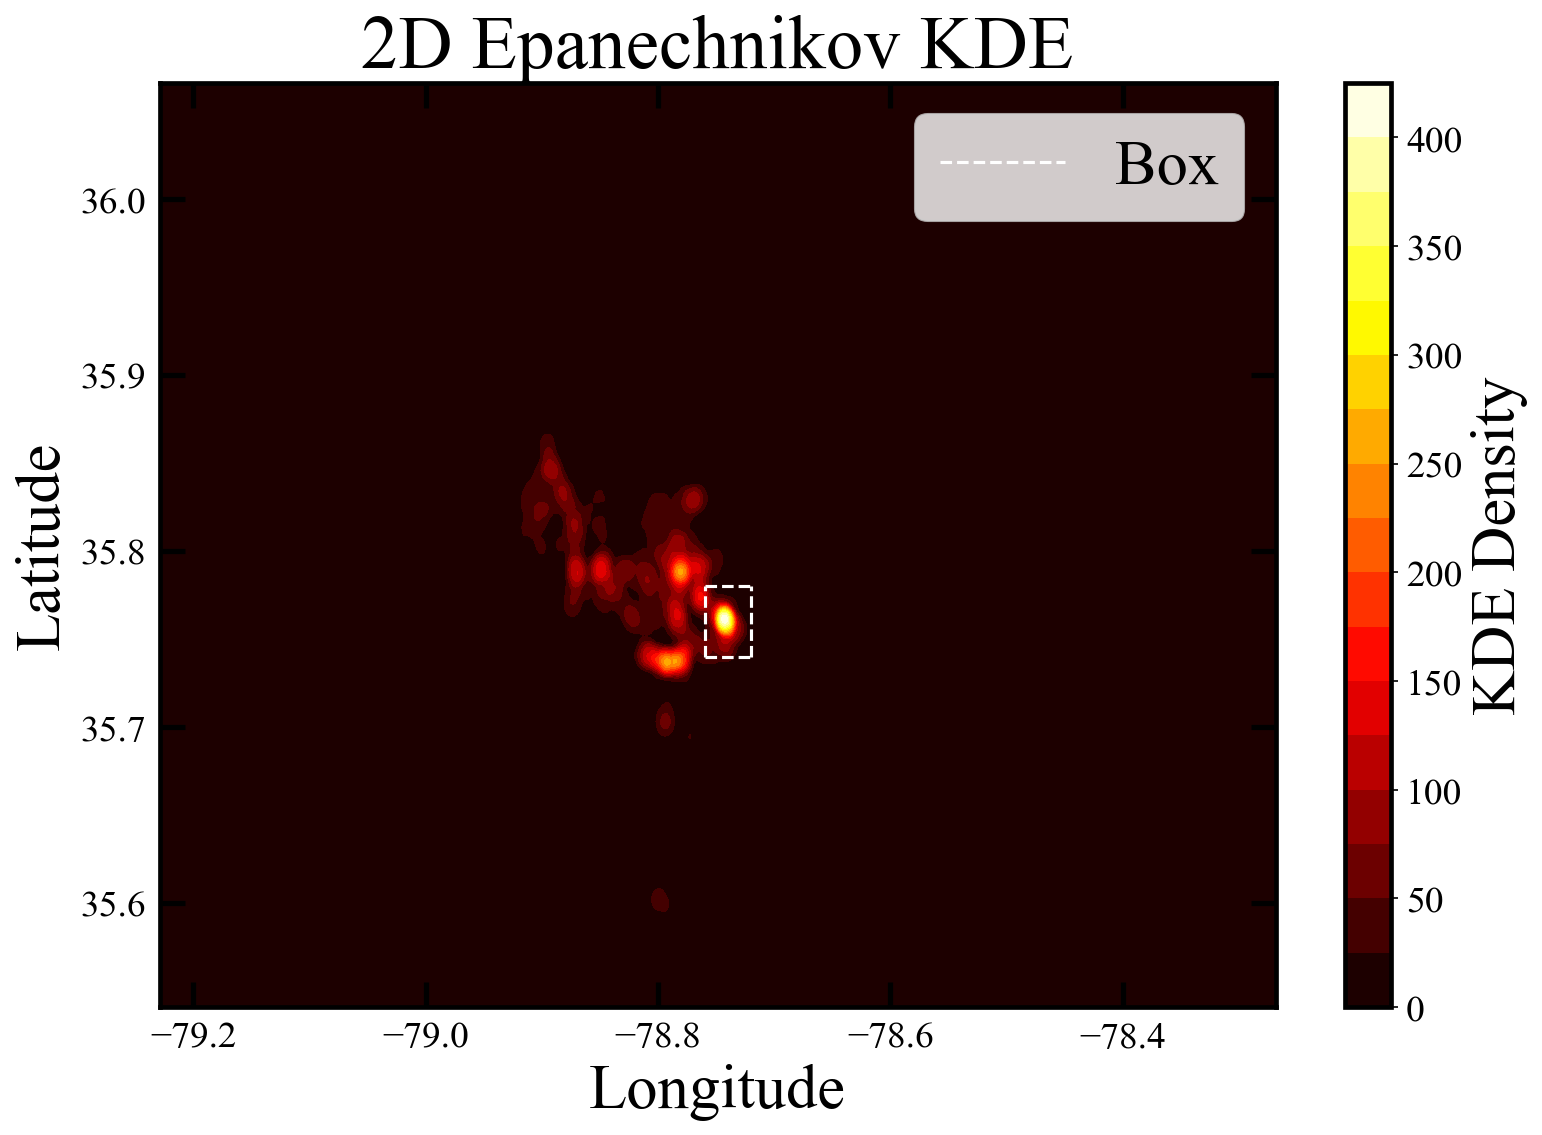

424.66577839964845


In [14]:
lat_ranges = (35.74,35.78)
lon_ranges = (-78.76,-78.72)
fig, ax = plt.subplots(figsize=(12, 8))
contour = ax.contourf(LO, LA, density_2d, levels=20, cmap='hot')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("2D Epanechnikov KDE")
cbar = plt.colorbar(contour, ax=ax, label=f"KDE Density")
ax.vlines([-78.76, -78.72], lat_ranges[0], lat_ranges[1], colors='white', linestyles='dashed', label="Box")
ax.hlines([35.74, 35.78], lon_ranges[0], lon_ranges[1], colors='white', linestyles='dashed')
ax.legend()
ax.grid(False)
stylize_ticks(fig, ax)
plt.show()
print(np.max(density_2d))



In [15]:
# Create a fine 2D grid covering the entire data range
lon_grid_full = np.linspace(longitude.min(), longitude.max(), 500)
lat_grid_full = np.linspace(latitude.min(), latitude.max(), 500)
LON_full, LAT_full = np.meshgrid(lon_grid_full, lat_grid_full)

# Flatten for KDE evaluation
grid_points_full = np.column_stack([LON_full.ravel(), LAT_full.ravel()])

# Evaluate KDE on the full grid
log_density_full = kde_2d.score_samples(grid_points_full)
density_full = np.exp(log_density_full).reshape(LON_full.shape)


integral_lon_full = integrate.trapezoid(density_full, lon_grid_full, axis=1)
integral_full = integrate.trapezoid(integral_lon_full, lat_grid_full)

print(f"Integral of KDE over entire domain: {integral_full:.6f}")


Integral of KDE over entire domain: 0.999558


In [16]:
lat_ranges = (35.74, 35.78)
lon_ranges = (-78.76, -78.72)


# Create 2D grid for the box region
lon_grid = np.linspace(lon_ranges[0], lon_ranges[1], 200)
lat_grid = np.linspace(lat_ranges[0], lat_ranges[1], 200)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

# Flatten for KDE evaluation
grid_points = np.column_stack([LON.ravel(), LAT.ravel()])

# Evaluate KDE on the grid
log_density_box = kde_2d.score_samples(grid_points)
density_box = np.exp(log_density_box).reshape(LON.shape)

# Integrate using 2D trapezoidal rule
from scipy.integrate import trapezoid
integral_lon = trapezoid(density_box, lon_grid, axis=1)
integral_box = trapezoid(integral_lon, lat_grid)

print(f"Integral of KDE over box: {integral_box:.6f}")

Integral of KDE over box: 0.137174
